# ResNet-50 Experiment 07 — Full layer4 Unfreeze with L1 Regularisation (No Dropout)

## Objective
Determine whether L1 regularisation alone (without L2 or Dropout) can match or exceed the performance of combined L1+L2+Dropout (iteration 05), by isolating the sparsity effect of L1 on the fine-tuned layer4 weights.

## Architecture Changes

| Component | 05. layer4 + L1+L2 | 07. layer4 + L1 only |
|---|---|---|
| Unfrozen layers | `layer4` (all 3 blocks) | `layer4` (all 3 blocks) |
| Trainable params | ~15M | ~15M |
| Weight decay (AdamW) | 1e-3 | 1e-3 |
| L1 lambda | 1e-3 | **1e-3** |
| L2 lambda | 1e-3 | **0** |
| LR — layer4 | 1e-4 | 1e-4 |
| LR — FC head | 1e-3 | 1e-3 |
| Dropout | 0.5 | **0 (removed)** |
| Epochs | 30 | 30 |

## Hypothesis
L1 regularisation promotes sparsity — it drives less-useful weights toward zero rather than just shrinking them. Since AdamW already provides L2-style weight shrinkage via `weight_decay=1e-3`, the L2 penalty in iteration 05 was partially redundant. Dropout and L1 both act as regularisers — stacking them may cause the FC head to underfit. With L1 providing regularisation on the backbone weights and AdamW weight decay handling shrinkage, removing both L2 and Dropout isolates the sparsity effect and gives the FC head more capacity to express the learned features.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet50
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_resnet50(num_classes=1, freeze_backbone=True, dropout=0.0).to(device)

for param in model.layer4.parameters():
    param.requires_grad = True

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),     'lr': 1e-3},
], weight_decay=1e-3)

num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: None')

Trainable params: 14,966,785 / 23,510,081
L1 lambda: 0.001 | L2 lambda: 0.0 | Dropout: None


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/resnet50_layer4_l1_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/30]
  Train | Loss: 0.9488, Bal Acc: 0.7070, Recall: 0.7400, F2: 0.5010, AUC: 0.7979
  Val   | Loss: 0.8749, Bal Acc: 0.7499, Recall: 0.9025, F2: 0.5674, AUC: 0.8555
  -> Saved best model (val AUC: 0.8555)


Epoch [2/30]
  Train | Loss: 0.8380, Bal Acc: 0.7747, Recall: 0.8312, F2: 0.5839, AUC: 0.8554
  Val   | Loss: 0.8231, Bal Acc: 0.7773, Recall: 0.8729, F2: 0.5992, AUC: 0.8699
  -> Saved best model (val AUC: 0.8699)


Epoch [3/30]
  Train | Loss: 0.8332, Bal Acc: 0.7851, Recall: 0.8267, F2: 0.5985, AUC: 0.8612
  Val   | Loss: 0.8748, Bal Acc: 0.7902, Recall: 0.7415, F2: 0.6219, AUC: 0.8640


Epoch [4/30]
  Train | Loss: 0.8118, Bal Acc: 0.7812, Recall: 0.8062, F2: 0.5942, AUC: 0.8662
  Val   | Loss: 0.7805, Bal Acc: 0.7878, Recall: 0.8178, F2: 0.6146, AUC: 0.8814
  -> Saved best model (val AUC: 0.8814)


Epoch [5/30]
  Train | Loss: 0.8265, Bal Acc: 0.7834, Recall: 0.8164, F2: 0.5967, AUC: 0.8634
  Val   | Loss: 0.8632, Bal Acc: 0.7590, Recall: 0.6864, F2: 0.5757, AUC: 0.8583


...

Epoch [26/30]
  Train | Loss: 0.6143, Bal Acc: 0.8433, Recall: 0.8757, F2: 0.6832, AUC: 0.9240
  Val   | Loss: 0.7389, Bal Acc: 0.8006, Recall: 0.8093, F2: 0.6337, AUC: 0.8962


Epoch [27/30]
  Train | Loss: 0.5924, Bal Acc: 0.8525, Recall: 0.8860, F2: 0.6972, AUC: 0.9298
  Val   | Loss: 0.7435, Bal Acc: 0.8013, Recall: 0.8263, F2: 0.6335, AUC: 0.8975


Epoch [28/30]
  Train | Loss: 0.5968, Bal Acc: 0.8481, Recall: 0.8723, F2: 0.6922, AUC: 0.9278
  Val   | Loss: 0.7374, Bal Acc: 0.8042, Recall: 0.8517, F2: 0.6361, AUC: 0.8978


Epoch [29/30]
  Train | Loss: 0.6164, Bal Acc: 0.8445, Recall: 0.8757, F2: 0.6852, AUC: 0.9234
  Val   | Loss: 0.7333, Bal Acc: 0.8019, Recall: 0.8432, F2: 0.6334, AUC: 0.8988


Epoch [30/30]
  Train | Loss: 0.5697, Bal Acc: 0.8577, Recall: 0.8951, F2: 0.7044, AUC: 0.9356
  Val   | Loss: 0.7340, Bal Acc: 0.8014, Recall: 0.8220, F2: 0.6340, AUC: 0.8985


## Plot Train and Validation Curves

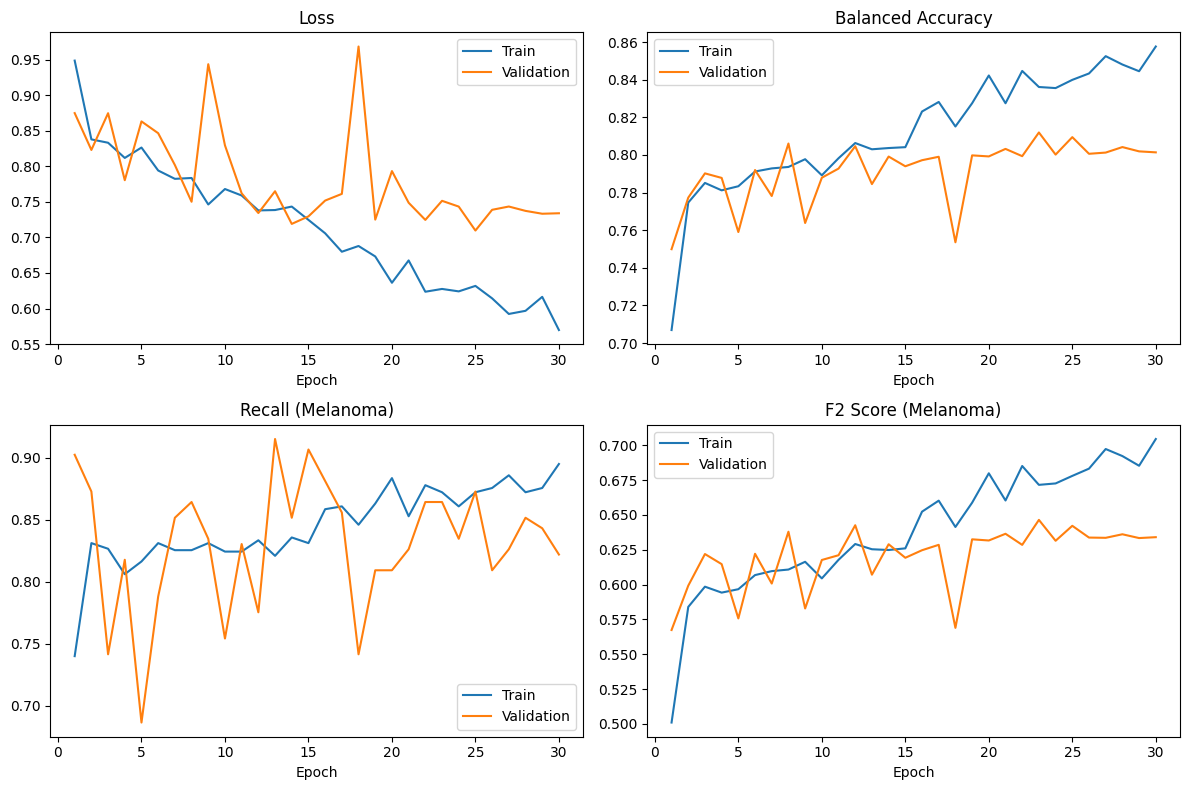

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet50_layer4_l1_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.54 | Val F2: 0.6536


## Test Set Evaluation

Threshold:          0.54
AUC-ROC:            0.8861
Balanced Accuracy:  0.7863
F2 Score:           0.6074

              precision    recall  f1-score   support

Non-Melanoma     0.9688    0.7657    0.8554      1340
    Melanoma     0.3053    0.8070    0.4430       171

    accuracy                         0.7704      1511
   macro avg     0.6371    0.7863    0.6492      1511
weighted avg     0.8937    0.7704    0.8087      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


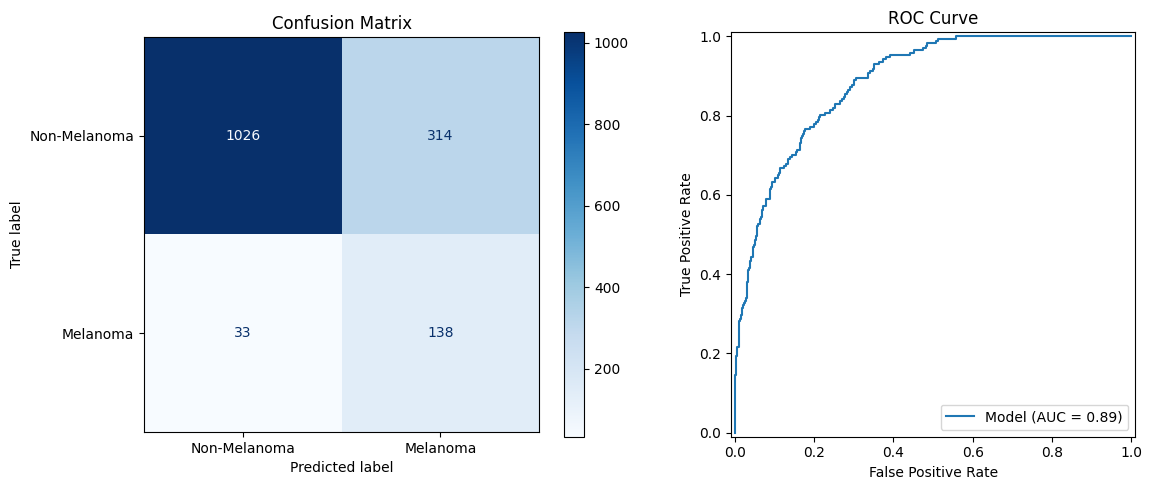

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)